# Compute 21cm $\Delta T_B$ box and Visualise it

### Overview
- [Initialisation](#Initialisation)
	- Define cosmological and astrophysical parameters 
	- Define data paths
	- File read and write
- [Visualise a slice](#Visualise:-A-slice)
	- Make a slice plot
- [Compute $\Delta T_B$ boxes](#compute-dTb) [**TODO**]
	- Visualise all fields at a given redshift
	- Plot global 21cm signal and all quantities
- [Build Lightcones](#Coeval-Boxes-vs-Lightcones)
- [Exercises](#Exercises) [**TODO**]

## Initialisation

In [24]:
# ------------------------------------------------------------------
# INITIALISATION
# ------------------------------------------------------------------

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

# ------------------------------------------------------------------
# Cosmological Parameters (Planck 2018)
# ------------------------------------------------------------------
h = 0.6774              # Hubble parameter
H0 = h * 3.24e-18       # H0 in units of /s
Tcmb0 = 2.725           # CMB temperature at z=0 (K)
omega_m = 0.3089        # Matter density parameter
omega_b = 0.049         # Baryon density parameter
omega_l = 1 - omega_m   # Dark energy density parameter
y_H = 0.76              # Hydrogen mass fraction
y_He = 0.24             # Helium mass fraction

# Physical constants (CGS)
c = 3e10                # Speed of light (cm/s)
k_B = 1.38e-16          # Boltzmann constant (erg/K)
m_H = 1.67e-24          # Hydrogen mass (g)
nu_21 = 1.4204e9        # 21cm frequency (Hz)
A_21 = 2.85e-15         # Einstein A coefficient for 21cm (Hz)
T_star = 0.068          # T* = h*nu_21/k_B (K)

# Derived quantities for Wouthuysen-Field coupling
nu_alpha = 2.468e15     # Lyman-alpha frequency (Hz)
A_alpha = 6.2581e8      # Einstein A coefficient for Ly-alpha (Hz)
f_alpha = 0.4162        # Oscillator strength

# ------------------------------------------------------------------
# Adiabatic Matter Temperature
# ------------------------------------------------------------------
# After thermal decoupling from the CMB (z_dec ~ 137), baryons cool 
# adiabatically as T_m ∝ (1+z)^2 (faster than CMB which cools as 1+z)
z_dec = 137.0  # Decoupling redshift

def T_adiabatic(z):
    """
    Compute the adiabatic matter temperature at redshift z.
        
    Parameters
    ----------
    z : float or array
        Redshift
    
    Returns
    -------
    float or array
        Adiabatic matter temperature [K]
    """
    T_cmb_dec = Tcmb0 * (1 + z_dec)  # CMB temp at decoupling
    return T_cmb_dec * ((1 + z) / (1 + z_dec))**2

### Data Requirements

Expected input files in `boxes/` directory:

| Field | Filename Pattern | Description |
|-------|-----------------|-------------|
| density | `density_ngrid{N}_z{z}` | Neutral hydrogen density |
| ionization | `qi_ngrid{N}_z{z}_zeta{zeta}_log10Mmin{log10Mmin}` | Ionization fraction $x_{\rm HII}$ |
| temperature | `Tk_fx={fx}_alpha={α}_ngrid{N}_z{z}` | Kinetic temperature [K] |
| J_alpha | `J_alpha_fL={fL}_ngrid{N}_z{z}` | Lyman-alpha flux |

In [4]:
# ------------------------------------------------------------------
# Data Configuration
# ------------------------------------------------------------------

#redshifts = [12.0, 10.0, 8.0, 7.0, 6.0]  # Redshift list 
redshifts = np.linspace(5.0, 25.0, 41)  # Redshift list from z=5 to z=25 in steps of 0.5
n_len = 32					# Grid resolution (N^3 cells)
box_len = 256.0 / h			# Comoving box size (cMpc)

# Directory paths
# base_repo = Path('./')
# input_dir = base_repo / 'boxes'	# Check: Put correct data path here
input_dir = Path(r'C:\Users\gaura\Downloads\input_boxes')
output_dir = Path('./outputs')
output_dir.mkdir(exist_ok=True, parents=True)

# ------------------------------------------------------------------
# Simulation/Model Parameters
# ------------------------------------------------------------------

# Reionization parameters
zeta = 8.00             # Ionization efficiency CHANGE EITHER 8 OR 16
log10Mmin = 8.00        # Minimum halo mass

# X-ray heating parameters
fx = 10.00               # X-ray efficiency CHANGE EITHER 1,10,100
alpha = 1.5             # X-ray spectral index

# Lyman-alpha parameters  
fL = 1.00               # Lyman-alpha efficiency CHANGE EITHERR 0.1,1,10

# ------------------------------------------------------------------
# File naming Convention
# ------------------------------------------------------------------

def field_path(field, z):
    """
    Generate path for a given field, redshift and modelling parameters
    
    Parameters
    ----------
    field : str
        Field name: 'density', 'ionization', 'temperature', 'J_alpha'
    z : float
        Redshift
    
    Returns
    -------
    Path
        Full path to the data file
    """
    z_str = f'{z:06.2f}'
    
    if field == 'density':
        # Neutral hydrogen density field
        fname = f"density_ngrid{n_len:04d}_z{z_str}"
    
    elif field == 'ionization' or field == 'qi':
        # Ionization fraction field
        fname = f"qi_ngrid{n_len:04d}_z{z_str}_zeta{zeta:06.2f}_log10Mmin{log10Mmin:05.2f}"
    
    elif field == 'temperature' or field == 'Tk':
        # Kinetic temperature field (X-ray heated)
        fname = f"Tk_fx={fx:07.2f}_alpha={alpha:04.1f}_ngrid{n_len:04d}_z{z_str}"
    
    elif field == 'J_alpha':
        # Lyman-alpha flux field
        fname = f"J_alpha_fL={fL:07.2f}_ngrid{n_len:04d}_z{z_str}"

    elif field == 'y_alpha':
        # Lyman-alpha y parameter field
        fname = f"y_alpha_fx={fx:07.2f}_alpha={alpha:04.1f}_fL={fL:07.2f}_ngrid{n_len:04d}_z{z_str}"

    elif field == 'dTb':
		# 21cm brightness temperature field
        fname = f"dTb_fx={fx:07.2f}_alpha={alpha:04.1f}_fL={fL:07.2f}_ngrid{n_len:04d}_z{z_str}_zeta{zeta:06.2f}_log10Mmin{log10Mmin:05.2f}"
    
    else:
        raise ValueError(f"Unknown field: {field}")
    
    return input_dir / fname

print(f"redshifts: {redshifts}")
print(f"Grid size: {n_len}^3")
print(f"Box size: {box_len:.2f} cMpc")
print(f"\nExample file paths:")
for field in ['density', 'ionization', 'temperature', 'J_alpha', 'dTb']:
    print(f"  {field}: {field_path(field, 10.0).name}")

NameError: name 'np' is not defined

In [26]:
# ------------------------------------------------------------------
# Reading and Writing Fortran Binary Data
# ------------------------------------------------------------------
# All data files are in Fortran unformatted binary format.

def ftopy_box(box):
    """
    Convert a Fortran-ordered binary array to Python (C) ordering.
    
    Fortran stores arrays in column-major order, 
    while Python/C uses row-major order. 
    
    This function also removes the padding bytes that
    Fortran adds at the start and end of unformatted records.
    
    Parameters
    ----------
    box : np.ndarray
        Flat array read from Fortran binary file
    
    Returns
    -------
    np.ndarray
        3D array in Python ordering
    """
    # Remove Fortran record markers (first and last elements)
    box = box[1:-1]
    # Reshape to 3D
    box = np.reshape(box, [n_len, n_len, n_len])
    # Transpose from Fortran to C ordering
    box = box.transpose(2, 1, 0)
    return box

def read_box(field, z):
    """
    Read a field box for a given redshift from Fortran binary file.
    
    Parameters
    ----------
    field : str
        Field name (e.g., 'density', 'ionization', 'temperature', 'J_alpha')
    z : float
        Redshift
    
    Returns
    -------
    np.ndarray
        3D box of shape (n_len, n_len, n_len)
    
    Raises
    ------
    FileNotFoundError
        If the data file does not exist
    """
    
    filepath = field_path(field, z)
    
    if not filepath.exists():
        raise FileNotFoundError(f"Data file not found: {filepath}")
    
    with open(filepath, 'rb') as f:
	    box = np.fromfile(f, dtype=np.float32)
    box = ftopy_box(box)
    
#    print(f'Loaded {field} at z={z:.1f} from {filepath.name}')
    return box

def write_box(box, field, z):
    """
    Write a 3D box in Fortran unformatted binary format.
    
    Parameters
    ----------
    box : np.ndarray
        3D array to save
    field : str
        Field name 
    z : float
        Redshift
    """
    
    filepath = field_path(field, z)
        
    n_len = box.shape[0]
    # Transpose from C to Fortran ordering
    box_f = box.transpose(2, 1, 0).astype(np.float32)
    # Flatten the array
    box_flat = box_f.flatten()
    # Add Fortran record markers
    record_size = np.array([n_len**3 * 4], dtype=np.int32)  # 4 bytes per float32
    with open(filepath, 'wb') as f:
        record_size.tofile(f)
        box_flat.tofile(f)
        record_size.tofile(f)
#    print(f"Saved box to {filepath}")

## Visualise: A slice

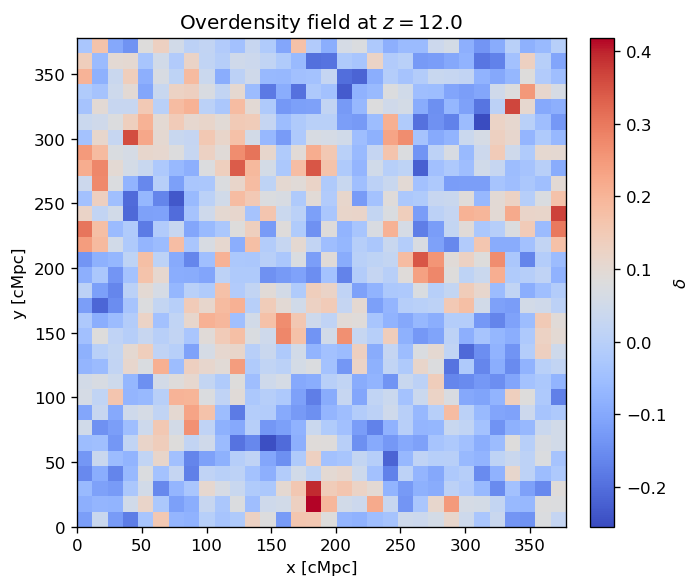

In [27]:
# ------------------------------------------------------------------
# Visualize Input Boxes: Slice Plots
# ------------------------------------------------------------------

def plot_slice(box, title='', cmap='viridis', slice_idx=None, direction='z', 
               vmin=None, vmax=None, extent=None, label=''):
    """
    Plot a 2D slice through a 3D box.
    
    Parameters
    ----------
    box : np.ndarray
        3D data array
    title : str
        Plot title
    cmap : str
        Colormap name
    slice_idx : int, optional
        Index of slice (default: middle)
    direction : str
        Slice direction: 'x', 'y', or 'z'
    vmin, vmax : float, optional
        Color scale limits
    extent : list, optional
        [xmin, xmax, ymin, ymax] in physical units
    label : str
        Colorbar label
    """
    n = box.shape[0]
    if slice_idx is None:
        slice_idx = n // 2
    
    if extent is None:
        extent = [0, box_len, 0, box_len]
    
    # Extract slice based on direction
    if direction == 'x':
        slc = box[slice_idx, :, :]
        xlabel, ylabel = 'y [cMpc]', 'z [cMpc]'
    elif direction == 'y':
        slc = box[:, slice_idx, :]
        xlabel, ylabel = 'x [cMpc]', 'z [cMpc]'
    else:  # direction == 'z'
        slc = box[:, :, slice_idx]
        xlabel, ylabel = 'x [cMpc]', 'y [cMpc]'
    
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(slc, origin='lower', cmap=cmap, extent=extent, 
                   vmin=vmin, vmax=vmax, aspect='equal')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if label:
        cb.set_label(label)
    plt.tight_layout()
    return fig, ax


# Example: visualize one field
fig, ax = plot_slice(read_box('density', 12.0), 
                      title=r'Overdensity field at $z=12.0$',
                      cmap='coolwarm', label=r'$\delta$')
plt.show()

<a id="compute-dTb"></a>

## Computing the 21cm Brightness Temperature

The 21cm brightness temperature contrast relative to the CMB is given by:

$$\Delta T_b \approx 27 \, x_{\rm HI} \, (1 + \delta_b) \left(\frac{1+z}{10}\right)^{1/2} \left(1 - \frac{T_{\rm CMB}}{T_S}\right) \quad [\text{mK}]$$
where:
- $x_{\rm HI}$ = neutral hydrogen fraction ($1 - x_{\rm HII}$)
- $\delta_b$ = baryon overdensity
- $z$ = redshift
- $T_{\rm CMB} = T_0 (1+z)$ = CMB temperature at redshift $z$
- $T_S$ = spin temperature

### The Spin Temperature

The spin temperature is determined by radiative coupling to the background radio photons ($T_{\rm CMB}$), collisional coupling to kinetic temperature $T_K$ and Wouthuysen-Field coupling to Lyman-$\alpha$ colour temperature $T_\alpha$:
$$T_S = \frac{T_{\rm CMB} + y_\alpha T_\alpha + y_c T_K}{1 + y_\alpha + y_c}$$

During cosmic dawn, we can ignore collisional coupling ($y_c \ll y_\alpha$) and $T_\alpha = T_K$, therefore:
$$T_S \approx \frac{T_{\rm CMB} + y_\alpha T_K}{1 + y_\alpha}$$

The Wouthuysen-Field coupling coefficient is:
$$y_\alpha = \frac{4}{27} \frac{c^2}{\nu_\alpha^2} \frac{A_\alpha}{A_{21}} T_\star \frac{J_\alpha}{T_K}$$
where $J_\alpha$ is the Lyman-alpha flux.

### Kinetic Temperature

The kinetic temperature $T_K$ has two components:

$$T_K = T_{\rm adiabatic}(z) + \Delta T_{\rm X-rays}$$

- **Adiabatic base**: After decoupling from the CMB at $z_{\rm dec} \sim 137$, baryons cool adiabatically: $T_a = T_{\rm CMB}(z_{\rm dec}) \times [(1+z)/(1+z_{\rm dec})]^2$
- **X-ray heating**: $\Delta T_{\rm X-rays}$ is the heating from X-ray sources, stored in the `Tk` files

### Task:
Using these equations
- Compute $T_K$ using $T_{\rm X-rays}$ and $T_{\rm adiabatic}$
- Compute $y_\alpha$ from $J_\alpha$ (save this box)
- Compute $T_S$ using $T_K$, $T_{\rm CMB}$ and $y_\alpha$
- Compute $\Delta T_B$ using $x_{\rm HI}$, $\delta$ and $T_S$ (save this box)

In [50]:
# ------------------------------------------------------------------
# Compute the 21cm Brightness Temperature Box
# ------------------------------------------------------------------

# y_alpha = factor * J_alpha / T_k
# From Furlanetto et al. (2006)
factor_yalpha = 2/9 * c**2 / nu_alpha**2 * A_alpha / A_21 * T_star

def compute_dTb(density, ionization, xrays_heat, J_alpha, z):
    """
    Computation of dTb from input fields.
    
    Note: The temperature field from the simulation contains only the 
    X-ray HEATING component. We must add the adiabatic base temperature.
    
    Parameters
    ----------
    density : np.ndarray
        Matter overdensity field (delta_b)
    ionization : np.ndarray
        Ionization fraction field (x_HII)
    xrays_heat : np.ndarray
        X-ray heating temperature field [K] (NOT total kinetic temperature!)
    J_alpha : np.ndarray
        Lyman-alpha intensity field
    z : float
        Redshift
    
    Returns
    -------
    np.ndarray
        21cm brightness temperature [mK]
    """
    
# Exercise: Your code here
# Follow the equations: Comput T_K, y_alpha, T_S, and finally dT_b
# Remember to save dTb and y_alpha boxes.

    #neutral fraction
    x_HI = np.clip(1.0 - ionization, 0.0, 1.0)
    delta_HI = (1.0+density)*x_HI

    # 1) CMB temperature at redshift z
    T_CMB = Tcmb0 * (1.0 + z)

    # 2) Adiabatic base temperature
    # T_ad = T0 * (1+z)^2 / (1+z_dec)
    # T_ad = Tcmb0 * (1.0 + z)**2 / (1.0 + z_dec)
    T_a = T_adiabatic(z)

    # 3) Total kinetic temperature
    # xrays_heat contains ONLY the X-ray heating component
    T_K = T_a + xrays_heat
    T_K = np.maximum(T_K, 1e-10)

    # 4) Wouthuysen-Field coupling coefficient
    # y_alpha = factor * J_alpha / T_K
    y_alpha = factor_yalpha * J_alpha / (T_K+1e-30)
    write_box(y_alpha, 'y_alpha', z)

    # 5) Spin temperature
    # T_S = (T_CMB + y_alpha*T_K) / (1 + y_alpha)
    T_S = (T_CMB + y_alpha * T_K) / (1.0 + y_alpha+1e-30)

    # Avoid division by zero
    T_S = np.maximum(T_S, 1e-10)
    contrast = 1.0 -(T_CMB / (T_S+1e-30))

    # 7) Brightness temperature [mK]
    dTb = 27.0 * delta_HI * contrast * np.sqrt((1.0 + z)/10.0)
    write_box(dTb, 'dTb', z)

    # dTb = prefactor * (1.0 - T_CMB / T_S)

    return dTb.astype(np.float32)

In [51]:
# ------------------------------------------------------------------
# Compute dTb for all redshifts and Save Results
# ------------------------------------------------------------------

for z in redshifts:
    print(f"\n--- Processing z = {z:.1f} ---")
    
    try:
        # Load input fields
        density = read_box('density', z)
        ionization = read_box('ionization', z)
        temperature = read_box('temperature', z)
        J_alpha = read_box('J_alpha', z)
        
        # Compute 21cm brightness temperature
        dTb = compute_dTb(density, ionization, temperature, J_alpha, z)
                
        # Print some statistics
        print(f"  dTb: min={dTb.min():.2f}, max={dTb.max():.2f}, mean={dTb.mean():.2f} mK")
        
    except FileNotFoundError as e:
        print(f"File not found for z={z:.1f}: {e}")
        exit()


--- Processing z = 5.0 ---
  dTb: min=0.00, max=0.00, mean=0.00 mK

--- Processing z = 5.5 ---
  dTb: min=0.00, max=9.71, mean=2.65 mK

--- Processing z = 6.0 ---
  dTb: min=0.00, max=10.87, mean=5.58 mK

--- Processing z = 6.5 ---
  dTb: min=0.00, max=12.04, mean=8.19 mK

--- Processing z = 7.0 ---
  dTb: min=0.00, max=13.05, mean=10.37 mK

--- Processing z = 7.5 ---
  dTb: min=0.00, max=14.16, mean=12.05 mK

--- Processing z = 8.0 ---
  dTb: min=0.00, max=15.47, mean=13.13 mK

--- Processing z = 8.5 ---
  dTb: min=0.00, max=16.45, mean=13.49 mK

--- Processing z = 9.0 ---
  dTb: min=0.00, max=17.00, mean=12.99 mK

--- Processing z = 9.5 ---
  dTb: min=1.19, max=18.84, mean=11.44 mK

--- Processing z = 10.0 ---
  dTb: min=-3.89, max=20.58, mean=8.66 mK

--- Processing z = 10.5 ---
  dTb: min=-10.67, max=22.49, mean=4.41 mK

--- Processing z = 11.0 ---
  dTb: min=-19.33, max=24.46, mean=-1.52 mK

--- Processing z = 11.5 ---
  dTb: min=-30.09, max=25.80, mean=-9.22 mK

--- Processing z

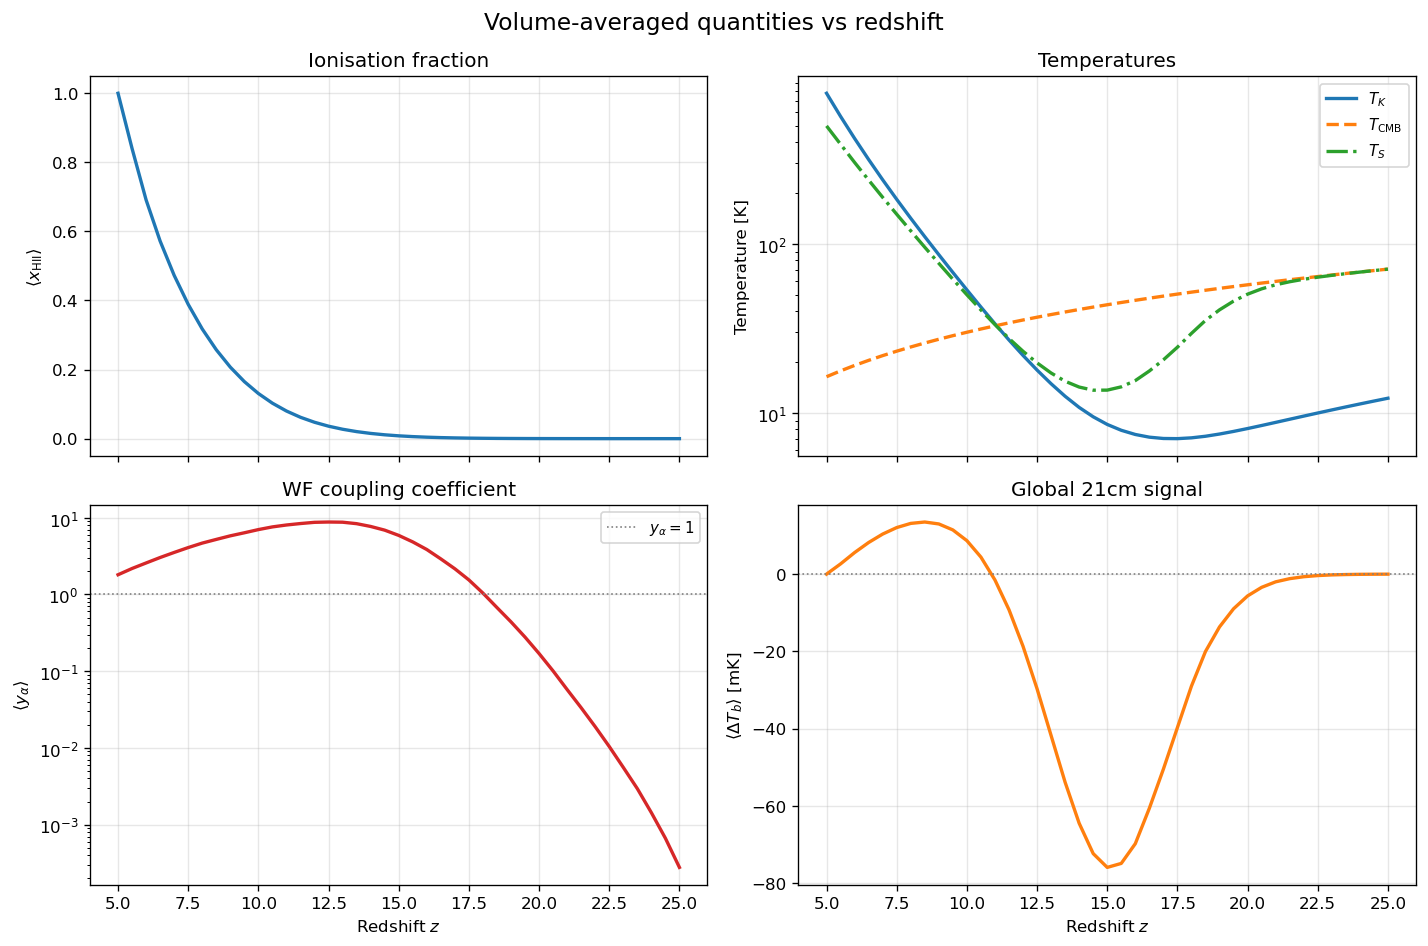

In [52]:
# ------------------------------------------------------------------
# Plot global (volume-averaged) quantities vs redshift
# ------------------------------------------------------------------

# Collect volume-averaged values at each redshift
global_z = []
global_xHII = []
global_Tk = []
global_yalpha = []
global_dTb = []
global_Tcmb = []
global_Ts = []

for z in redshifts:
    try:
        density     = read_box('density', z)
        ionization  = read_box('ionization', z)
        xrays_heat  = read_box('temperature', z)
        J_alpha_box = read_box('J_alpha', z)
        dTb_box     = read_box('dTb', z)
    except FileNotFoundError:
        continue

    T_a  = T_adiabatic(z)
    T_k  = xrays_heat + T_a
    T_cmb = Tcmb0 * (1.0 + z)
    y_alpha_box = factor_yalpha * J_alpha_box / (T_k + 1e-30)
    T_S = (T_cmb + y_alpha_box * T_k) / (1 + y_alpha_box + 1e-30)

    global_z.append(z)
    global_xHII.append(ionization.mean())
    global_Tk.append(T_k.mean())
    global_yalpha.append(y_alpha_box.mean())
    global_dTb.append(dTb_box.mean())
    global_Tcmb.append(T_cmb)
    global_Ts.append(T_S.mean())

global_z = np.array(global_z)

# ---- Plot ----
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# Panel 1: ionisation fraction
axes[0, 0].plot(global_z, global_xHII, 'C0-', lw=2)
axes[0, 0].set_ylabel(r'$\langle x_{\rm HII} \rangle$')
axes[0, 0].set_title('Ionisation fraction')
axes[0, 0].set_ylim(-0.05, 1.05)
axes[0, 0].grid(alpha=0.3)

# Panel 2: temperatures
axes[0, 1].semilogy(global_z, global_Tk,   label=r'$T_K$', lw=2)
axes[0, 1].semilogy(global_z, global_Tcmb, label=r'$T_{\rm CMB}$', ls='--', lw=2)
axes[0, 1].semilogy(global_z, global_Ts,   label=r'$T_S$', ls='-.', lw=2)
axes[0, 1].set_ylabel('Temperature [K]')
axes[0, 1].set_title('Temperatures')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(alpha=0.3)

# Panel 3: WF coupling
axes[1, 0].semilogy(global_z, global_yalpha, 'C3-', lw=2)
axes[1, 0].axhline(1, color='grey', ls=':', lw=1, label=r'$y_\alpha = 1$')
axes[1, 0].set_ylabel(r'$\langle y_\alpha \rangle$')
axes[1, 0].set_xlabel('Redshift $z$')
axes[1, 0].set_title('WF coupling coefficient')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(alpha=0.3)

# Panel 4: global 21cm signal
axes[1, 1].plot(global_z, global_dTb, 'C1-', lw=2)
axes[1, 1].axhline(0, color='grey', ls=':', lw=1)
axes[1, 1].set_ylabel(r'$\langle \Delta T_b \rangle$ [mK]')
axes[1, 1].set_xlabel('Redshift $z$')
axes[1, 1].set_title('Global 21cm signal')
axes[1, 1].grid(alpha=0.3)

fig.suptitle('Volume-averaged quantities vs redshift', fontsize=14)
plt.tight_layout()
plt.show()

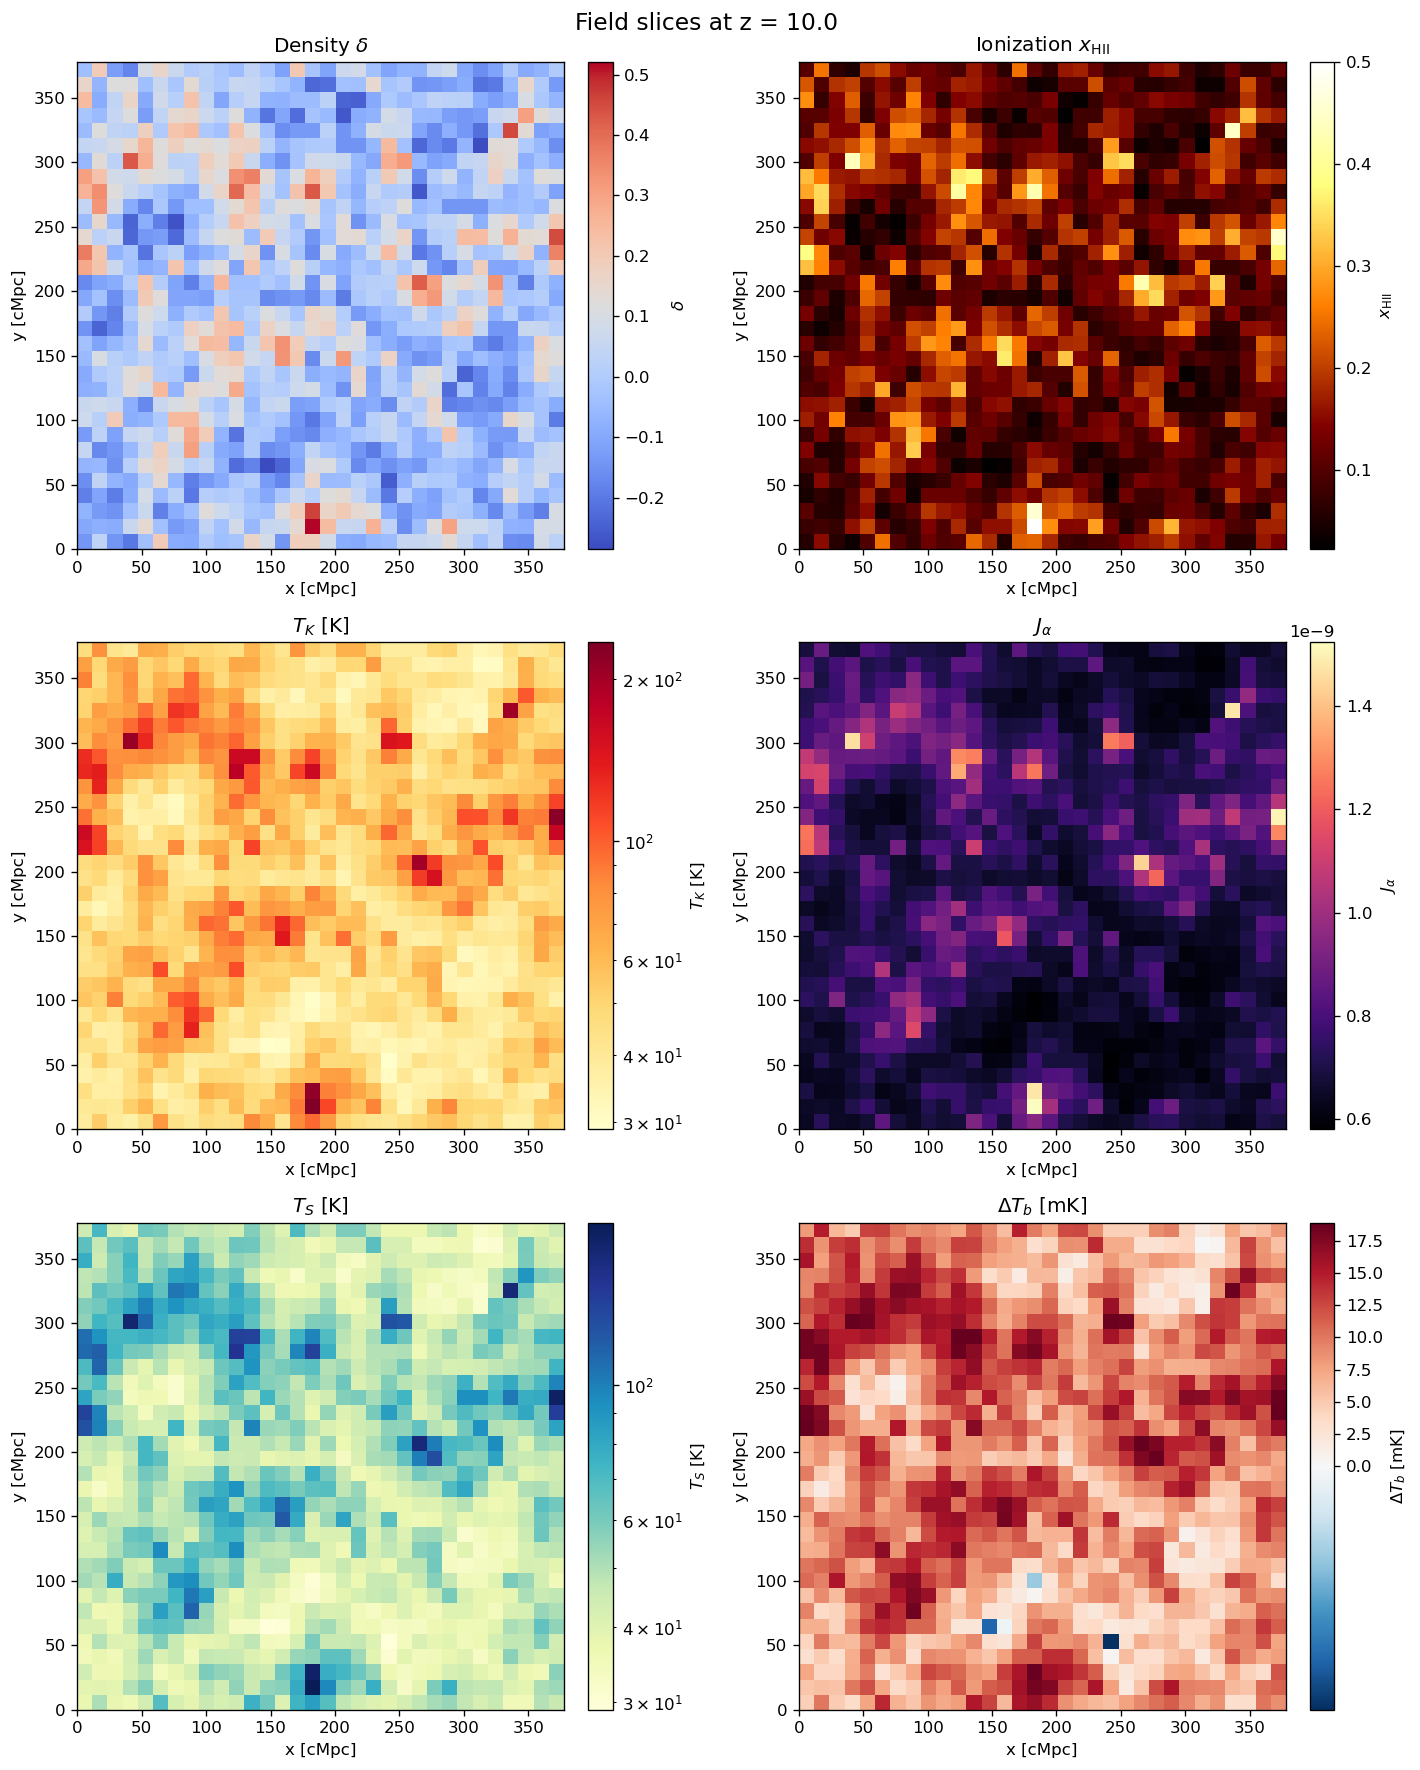

In [53]:
# ------------------------------------------------------------------
# Plot slices for each field at a chosen redshift
# ------------------------------------------------------------------

z_slice = 10.0

density     = read_box('density', z_slice)
ionization  = read_box('ionization', z_slice)
xrays_heat  = read_box('temperature', z_slice)
J_alpha_box = read_box('J_alpha', z_slice)
dTb_box     = read_box('dTb', z_slice)

# Compute derived fields for this redshift
T_a  = T_adiabatic(z_slice)
T_k  = xrays_heat + T_a
T_cmb = Tcmb0 * (1.0 + z_slice)
y_alpha_box = factor_yalpha * J_alpha_box / (T_k + 1e-30)
T_S_box = (T_cmb + y_alpha_box * T_k) / (1 + y_alpha_box + 1e-30)

slice_fields = [
    (density,     r'Density $\delta$',        'coolwarm',  r'$\delta$'),
    (ionization,  r'Ionization $x_{\rm HII}$', 'afmhot',    r'$x_{\rm HII}$'),
    (T_k,         r'$T_K$ [K]',               'YlOrRd',    r'$T_K$ [K]'),
    (J_alpha_box, r'$J_\alpha$',              'magma',     r'$J_\alpha$'),
    (T_S_box,     r'$T_S$ [K]',              'YlGnBu',    r'$T_S$ [K]'),
    (dTb_box,     r'$\Delta T_b$ [mK]',      'RdBu_r',    r'$\Delta T_b$ [mK]'),
]

from matplotlib.colors import LogNorm, TwoSlopeNorm

extent = [0, box_len, 0, box_len]
mid = n_len // 2

fig, axs = plt.subplots(3, 2, figsize=(12, 15))

for ax, (box, title, cmap, label) in zip(axs.flatten(), slice_fields):
    slc = box[:, :, mid]
    
    # Use log scale for temperature fields, diverging for dTb
    if 'T_K' in title or 'T_S' in title:
        norm = LogNorm(vmin=max(slc.min(), 1), vmax=slc.max())
        im = ax.imshow(slc, origin='lower', cmap=cmap, extent=extent, norm=norm, aspect='equal')
    elif 'Delta T_b' in title:
        norm = TwoSlopeNorm(vcenter=0, vmin=slc.min(), vmax=slc.max())
        im = ax.imshow(slc, origin='lower', cmap=cmap, extent=extent, norm=norm, aspect='equal')
    else:
        im = ax.imshow(slc, origin='lower', cmap=cmap, extent=extent, aspect='equal')
    
    ax.set_xlabel('x [cMpc]')
    ax.set_ylabel('y [cMpc]')
    ax.set_title(title)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(label)

fig.suptitle(f'Field slices at z = {z_slice:.1f}', fontsize=14)
plt.tight_layout()
plt.show()

## Coeval Boxes vs Lightcones

### Coeval Boxes
- All points in the box correspond to the same redshift (time). 
- From direct simulation outputs
- Statistically homogeneous and isotropic within the box
- Studying statistics at fixed redshift

### Lightcones
- What an observer actually sees. 
- Evolution of redshift along the line of sight direction.
	- We choose $z$-axis in the box as LoS.
- Constructed by stacking slices from different redshift boxes along the LoS

In [54]:
# ------------------------------------------------------------------
# Build a Lightcone Image
# ------------------------------------------------------------------
# z-axis is line of sight direction (redshift direction)
# We take slices perpendicular to z, then stack them to show evolution

def hubble(z):
    """Hubble parameter H(z) in s^-1 (matter + Lambda)."""
    return H0 * np.sqrt(omega_m * (1 + z)**3 + omega_l)

def dz_to_cells(z1, z2, n_steps=200):
    """
    Convert a redshift interval [z1, z2] to the corresponding number 
    of grid cells along the LoS, based on comoving distance.
    
    Parameters
    ----------
    z1, z2 : float
        Redshift bounds of the interval (z1 < z2).
    n_steps : int
        Number of integration steps (trapezoidal rule).
    
    Returns
    -------
    int
        Number of grid cells corresponding to the comoving distance.
    """
    zz = np.linspace(z1, z2, n_steps)
    integrand = c / hubble(zz)                     # cm / (1/s) = cm·s ≡ cm (since H in 1/s)
    chi_cm = np.trapz(integrand, zz)               # comoving distance in cm
    chi_mpc = chi_cm / 3.086e24                    # convert cm → Mpc
    cell_size = box_len / n_len                    # cMpc per cell
    return int(round(chi_mpc / cell_size))

def build_lightcone_2d(field):
    """
    Build a 2D lightcone by stacking slices from different redshifts.
    
    For each step dz the comoving distance is converted to a number of grid cells 
    and the slice index is incremented accordingly (with periodic boundary conditions).
    
    Parameters
    ----------
    field : str
        Name of the field to use

    Returns
    -------
    np.ndarray
        2D array: (transverse pixels, redshift steps)
    """
    
    columns = []
    los_slice = 0   # start at cell 0
    
    for i, z in enumerate(redshifts):
        try:
            cube = read_box(field, z)
        except FileNotFoundError:
            continue
        
        # Take a slice along z (LoS) at the current los_slice (periodic)
        xy_slice = cube[:, :, los_slice % n_len]
        
        # Pick the middle row from the slice
        profile = xy_slice[n_len // 2, :]
        columns.append(profile)
        
        # Advance los_slice for the next redshift step
        if i + 1 < len(redshifts):
            los_slice += dz_to_cells(redshifts[i], redshifts[i + 1])
    
    if not columns:
        return None
    
    # Stack: shape (n_transverse, n_redshifts)
    return np.stack(columns, axis=1)

# Build lightcones for various fields
lightcone_fields = ['ionization', 'temperature', 'y_alpha', 'T_S', 'dTb']

lightcones = {}
for name in lightcone_fields:
    if name == 'T_S':
        # T_S is a derived field — build its lightcone from temperature + J_alpha
        columns = []
        los_slice = 0
        for i, z in enumerate(redshifts):
            try:
                xrays = read_box('temperature', z)
                Ja    = read_box('J_alpha', z)
            except FileNotFoundError:
                continue
            Ta   = T_adiabatic(z)
            Tk   = xrays + Ta
            Tcmb = Tcmb0 * (1.0 + z)
            ya   = factor_yalpha * Ja / (Tk + 1e-30)
            Ts   = (Tcmb + ya * Tk) / (1 + ya + 1e-30)
            xy_slice = Ts[:, :, los_slice % n_len]
            columns.append(xy_slice[n_len // 2, :])
            if i + 1 < len(redshifts):
                los_slice += dz_to_cells(redshifts[i], redshifts[i + 1])
        lightcones[name] = np.stack(columns, axis=1) if columns else None
    else:
        lightcones[name] = build_lightcone_2d(name)

print("Built 2D lightcones for:", list(lightcones.keys()))

Built 2D lightcones for: ['ionization', 'temperature', 'y_alpha', 'T_S', 'dTb']


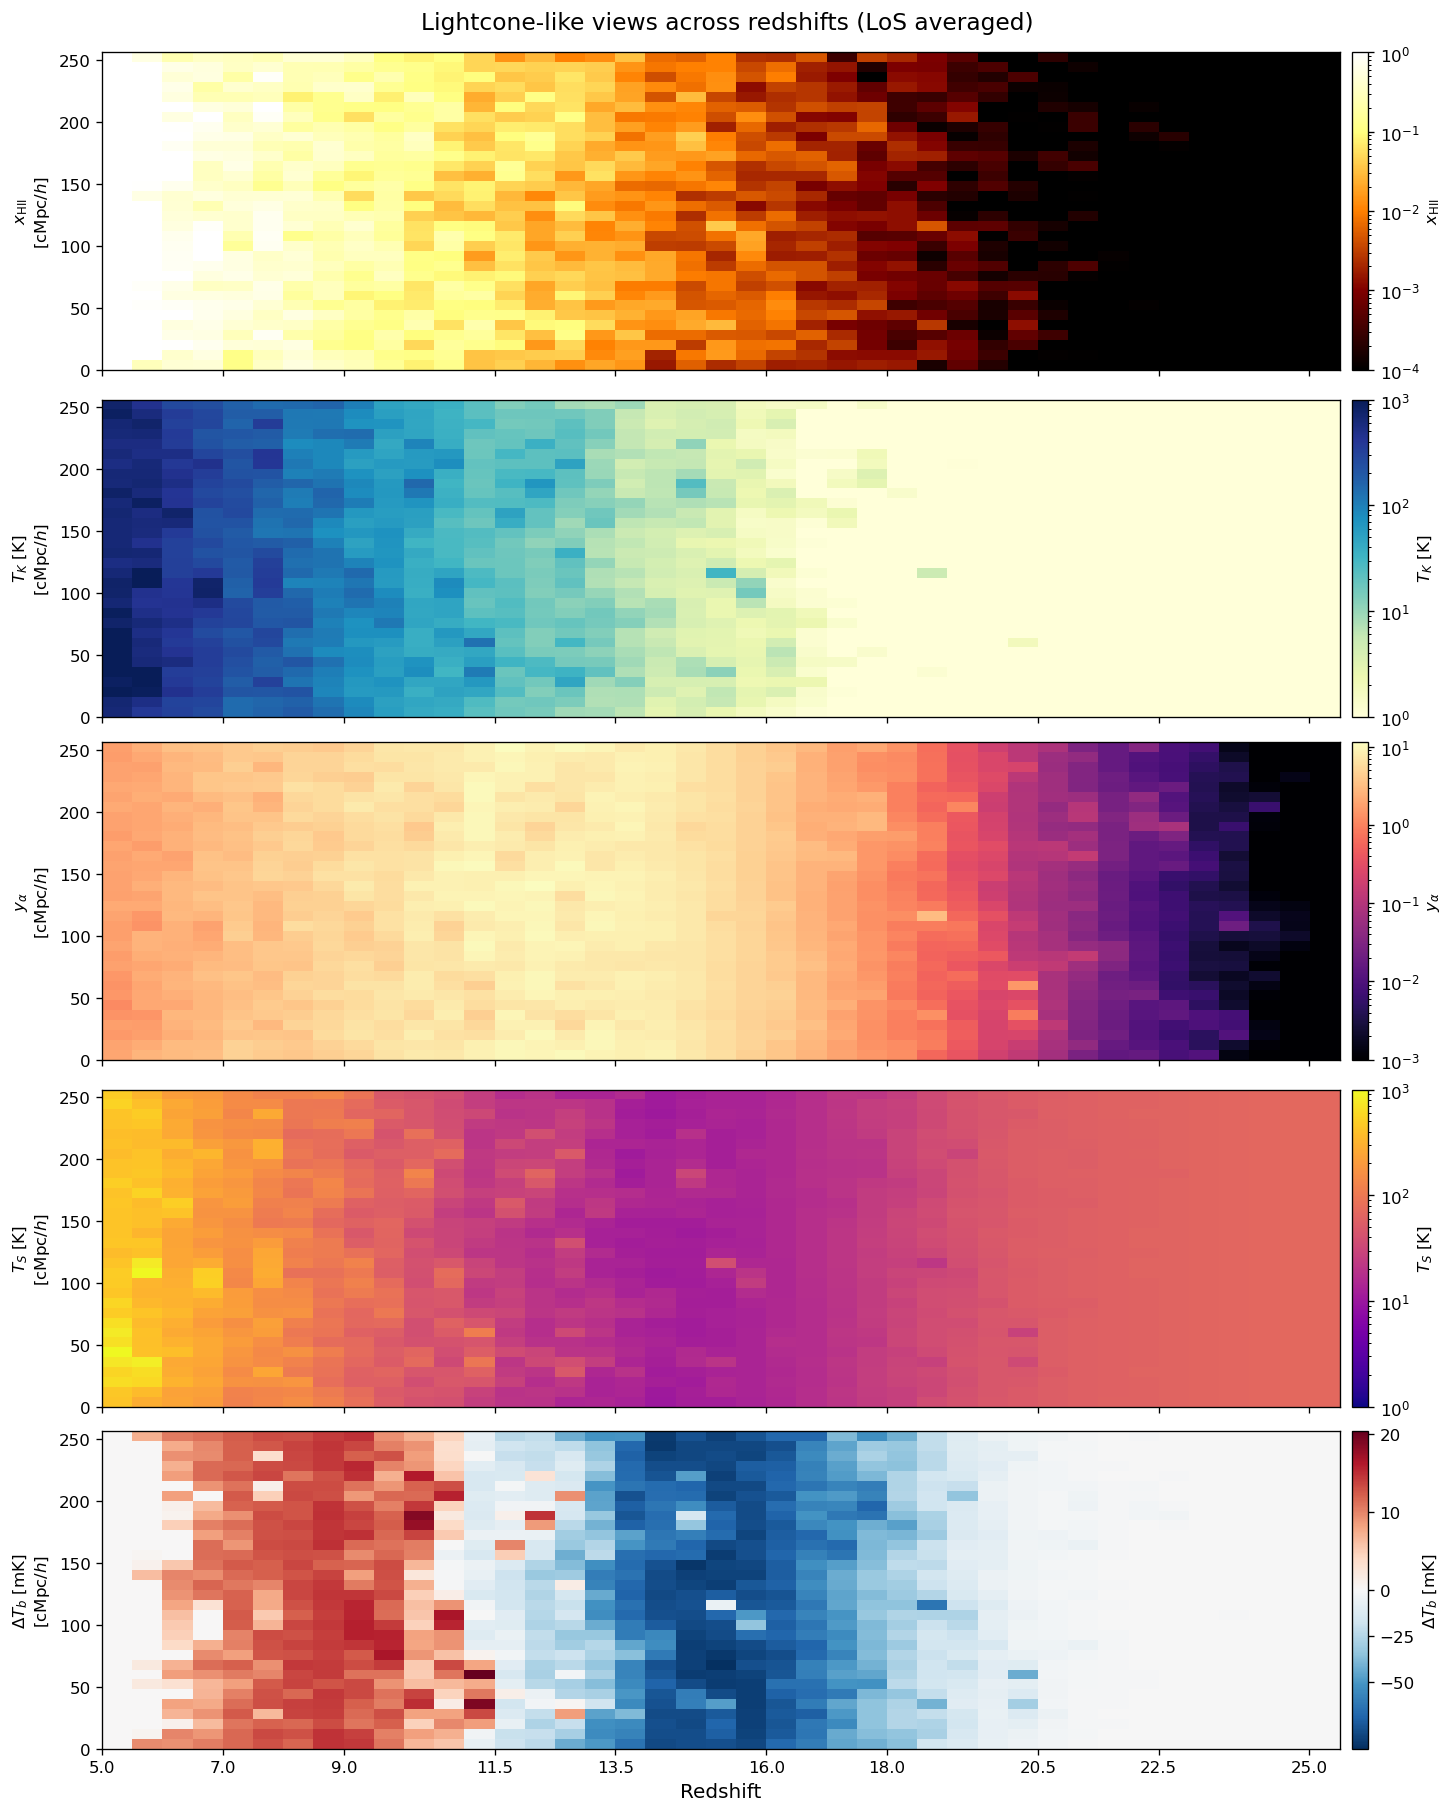

In [55]:
# ------------------------------------------------------------------
# Plot Lightcone Panels 
# ------------------------------------------------------------------
from matplotlib.colors import LogNorm, TwoSlopeNorm

# Colormaps for each field
cmaps = {
    'ionization': 'afmhot',
    'temperature': 'YlGnBu',
    'y_alpha': 'magma',
    'T_S': 'plasma',
    'dTb': 'RdBu_r',
}

# Colorbar labels
labels = {
    'ionization': r'$x_{\rm HII}$',
    'temperature': r'$T_K$ [K]',
    'y_alpha': r'$y_\alpha$',
    'T_S': r'$T_S$ [K]',
    'dTb': r'$\Delta T_b$ [mK]',
}

# Ranges for each field
lightcone_limits = {
    'ionization': {'vmin': 1e-4, 'vmax': 1.0},      # Ionization fraction — log scale
    'temperature': {'vmin': 1, 'vmax': 1000},        # Kinetic temperature [K] — log scale
    'y_alpha': {'vmin': 1e-3, 'vmax': None},         # WF coupling coefficient — log scale
    'T_S': {'vmin': 1, 'vmax': 1000},                # Spin temperature [K] — log scale
    'dTb': {'vmin': None, 'vmax': None},             # Brightness temperature [mK] — auto from data
}

# Fields that should use log color scale
log_fields = {'temperature', 'y_alpha', 'ionization', 'T_S'}

# Physical extent for the transverse (y) axis
extent_phys = [0, len(redshifts), 0, box_len*h]   # [x0, x1, y0, y1]

if lightcones and any(lc is not None for lc in lightcones.values()):
    n_fields = len(lightcone_fields)
    fig, axs = plt.subplots(n_fields, 1, figsize=(12, 3 * n_fields), 
                            sharex=True, constrained_layout=True)
    fig.suptitle('Lightcone-like views across redshifts (LoS averaged)', fontsize=14)
        
    for i, (ax, name) in enumerate(zip(axs, lightcone_fields)):
        lc = lightcones[name]
        tick_vals = None
        if lc is None:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_ylabel(name)
            continue
        
        # Get realistic limits for this field
        limits = lightcone_limits.get(name, {})
        vmin = limits.get('vmin', None)
        vmax = limits.get('vmax', None)
        
        # Use log scale for temperature, y_alpha, and ionization
        if name in log_fields:
            lc_plot = np.clip(lc, vmin if vmin and vmin > 0 else 1e-30, None)
            norm = LogNorm(vmin=vmin if vmin and vmin > 0 else lc_plot[lc_plot > 0].min(), 
                           vmax=vmax if vmax else lc_plot.max())
            im = ax.imshow(lc_plot, origin='lower', aspect='auto',
                           cmap=cmaps.get(name, 'viridis'), norm=norm,
                           extent=extent_phys)
        elif name == 'dTb':
            # Compute data-driven limits when not explicitly set
            data_vmin = vmin if vmin is not None else float(lc.min())
            data_vmax = vmax if vmax is not None else float(lc.max())
            # Diverging norm centred at 0
            norm = TwoSlopeNorm(vcenter=0, vmin=data_vmin, vmax=data_vmax)
            im = ax.imshow(lc, origin='lower', aspect='auto',
                           cmap=cmaps.get(name, 'viridis'), norm=norm,
                           extent=extent_phys)
            # Explicit colorbar ticks spanning negative and positive values
            tick_vals = [-150, -100, -50, -25, 0, 10, 20, 30]
            tick_vals = [t for t in tick_vals if t >= data_vmin and t <= data_vmax]
        else:
            im = ax.imshow(lc, origin='lower', aspect='auto', 
                           cmap=cmaps.get(name, 'viridis'),
                           vmin=vmin, vmax=vmax,
                           extent=extent_phys)
        ax.set_ylabel(f'{labels.get(name, "")}\n[cMpc/$h$]')
        
        # Add colorbar on the right
        cb = plt.colorbar(im, ax=ax, location='right', pad=0.01)
        if tick_vals:
            cb.set_ticks(tick_vals)
        cb.set_label(labels.get(name, ''), fontsize=10)
    
    # Set x-axis labels only on bottom panel
    axs[-1].set_xlabel('Redshift', fontsize=12)
    
    # Set x-tick labels (redshift values)
    n_ticks = min(10, len(redshifts))
    tick_indices = np.linspace(0, len(redshifts)-1, n_ticks, dtype=int)
    axs[-1].set_xticks(tick_indices)
    axs[-1].set_xticklabels([f'{redshifts[i]:.1f}' for i in tick_indices])
    
    plt.show()
else:
    print("No lightcone data to plot. Run the processing cells first.")
    

  No data for $f_L$ = 0.1
  No data for $f_L$ = 10.0
  No data for $f_X$ = 1.0
  No data for $f_X$ = 100.0
  No data for $\zeta$ = 16.0


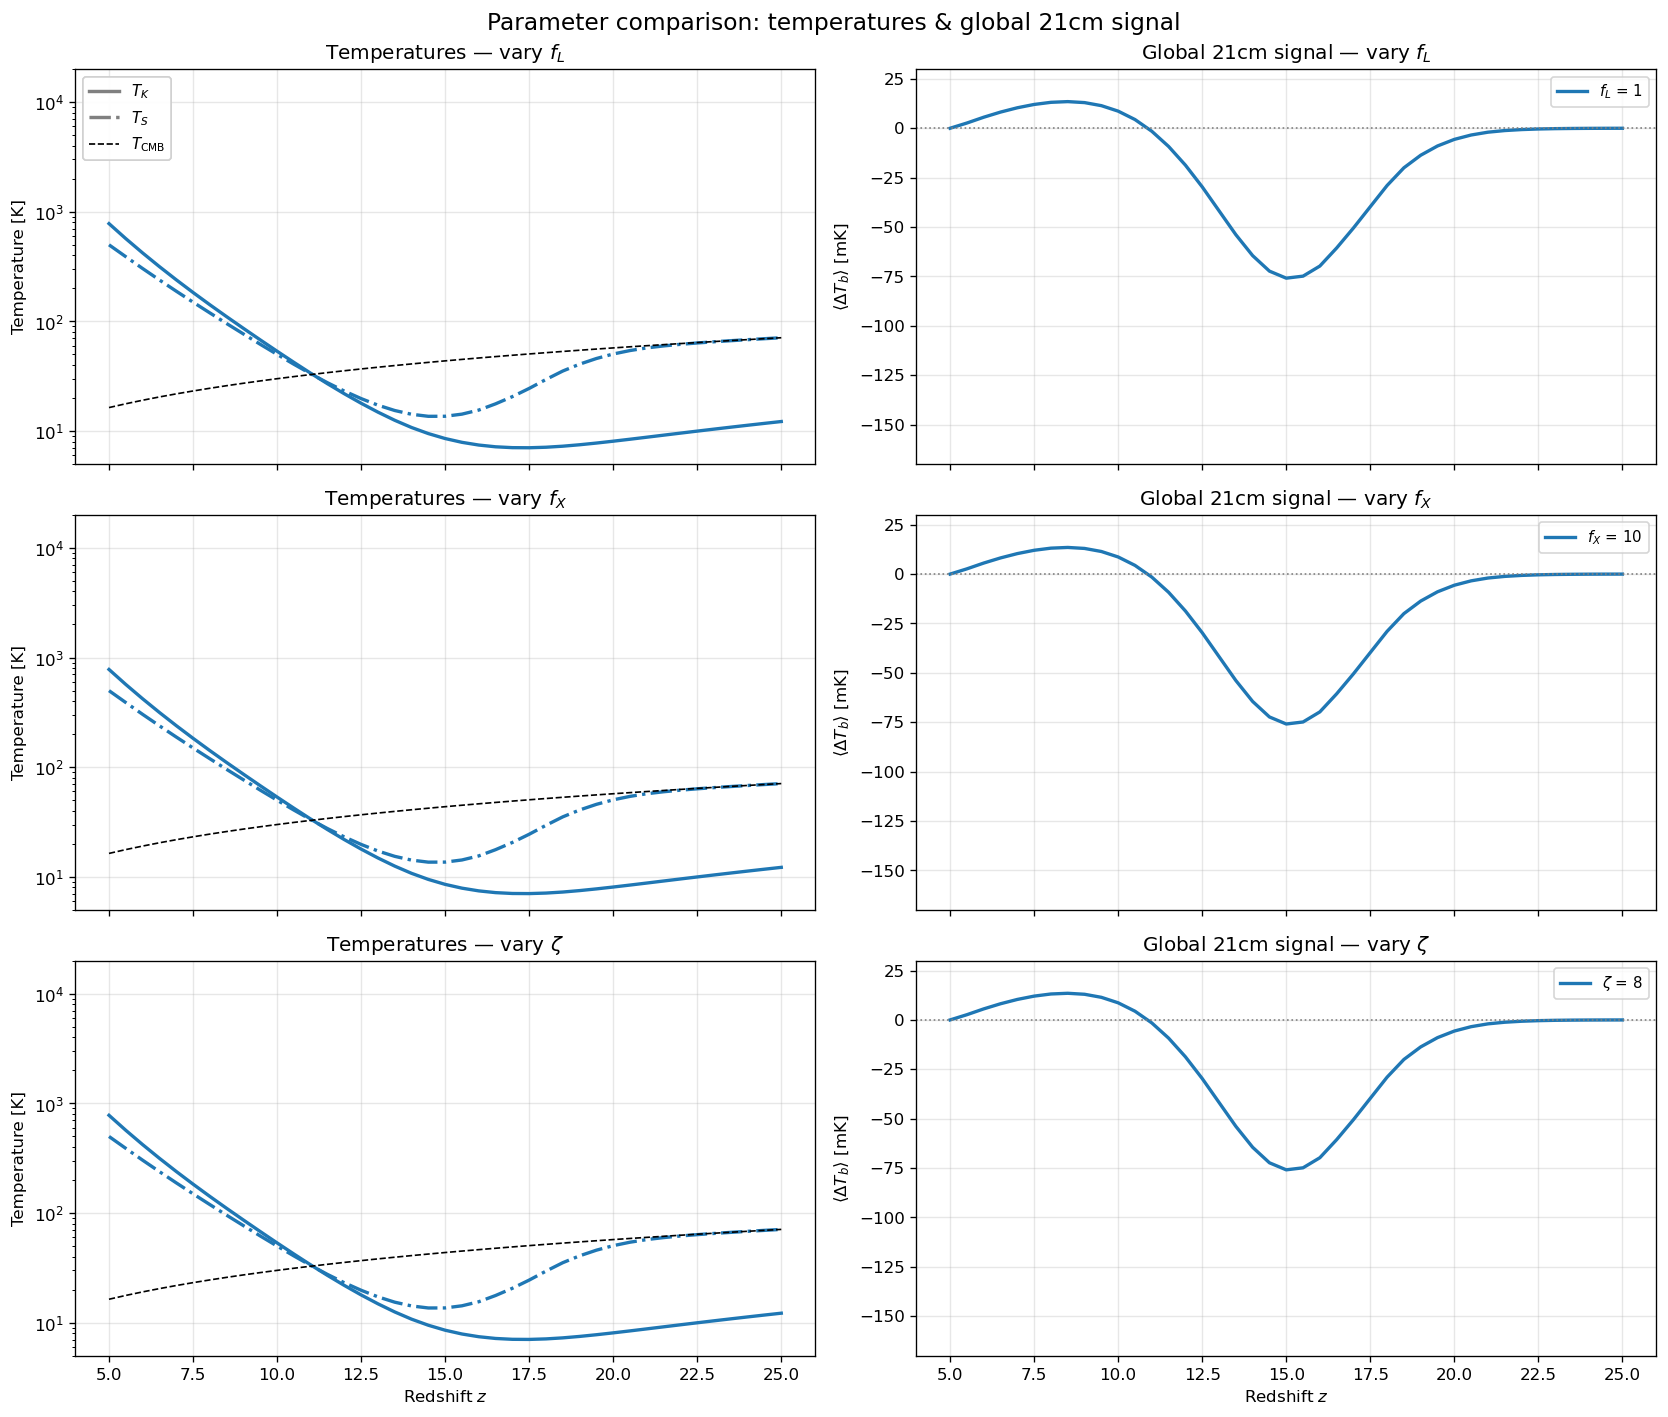

In [56]:
# ------------------------------------------------------------------
# Compare Global 21cm Signal for Different Model Parameters
# ------------------------------------------------------------------

# Fiducial parameter values
fx_fid   = 10
fL_fid   = 1
zeta_fid = 8

# Save original parameter values
fx_original   = fx
fL_original   = fL
zeta_original = zeta

def global_quantities_for_params():
    """Read all fields and return (z_arr, mean_Tk, Tcmb, mean_Ts, mean_dTb)."""
    z_arr, g_Tk, g_Tcmb, g_Ts, g_dTb = [], [], [], [], []
    for z_i in redshifts:
        try:
            xrays_heat  = read_box('temperature', z_i)
            J_alpha_box = read_box('J_alpha', z_i)
            dTb_box     = read_box('dTb', z_i)
        except FileNotFoundError:
            continue
        T_a   = T_adiabatic(z_i)
        T_k   = xrays_heat + T_a
        T_cmb = Tcmb0 * (1.0 + z_i)
        y_alpha_box = factor_yalpha * J_alpha_box / (T_k + 1e-30)
        T_S_box = (T_cmb + y_alpha_box * T_k) / (1 + y_alpha_box + 1e-30)

        z_arr.append(z_i)
        g_Tk.append(T_k.mean())
        g_Tcmb.append(T_cmb)
        g_Ts.append(T_S_box.mean())
        g_dTb.append(dTb_box.mean())
    return z_arr, g_Tk, g_Tcmb, g_Ts, g_dTb

# Parameter sweep definitions:  (row_label, param_name, values)
sweeps = [
    (r'$f_L$',    'fL',   [0.1, 1.0, 10.0]),
    (r'$f_X$',    'fx',   [1.0, 10.0, 100.0]),
    (r'$\zeta$',  'zeta', [8.0, 16.0]),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
color_ar = ['C0', 'C1', 'C2']

for row, (param_label, param_key, values) in enumerate(sweeps):
    ax_T   = axes[row, 0]
    ax_dTb = axes[row, 1]

    for val in values:
        # Reset to fiducial, then override the swept parameter
        fx   = fx_fid
        fL   = fL_fid
        zeta = zeta_fid
        if param_key == 'fL':
            fL = val
        elif param_key == 'fx':
            fx = val
        elif param_key == 'zeta':
            zeta = val

        z_arr, g_Tk, g_Tcmb, g_Ts, g_dTb = global_quantities_for_params()
        if not z_arr:
            print(f"  No data for {param_label} = {val}")
            continue

        lbl = f'{param_label} = {val:g}'
        color = color_ar[len(ax_T.lines) % len(color_ar)]
        ax_T.plot(z_arr, g_Tk,  lw=2, color=color)
        ax_T.plot(z_arr, g_Ts,  lw=2, color=color, ls='-.')
        ax_dTb.plot(z_arr, g_dTb, lw=2, color=color, label=lbl)

    # T_CMB is the same for all parameter values — plot once
    z_cmb = np.array(redshifts)
    ax_T.plot(z_cmb, Tcmb0 * (1 + z_cmb), 'k--', lw=1, label=r'$T_{\rm CMB}$')

    # In the first row only, add a line-style legend for T_K / T_S / T_CMB
    if row == 0:
        from matplotlib.lines import Line2D
        style_handles = [
            Line2D([], [], color='grey', ls='-',  lw=2, label=r'$T_K$'),
            Line2D([], [], color='grey', ls='-.', lw=2, label=r'$T_S$'),
            Line2D([], [], color='k',    ls='--', lw=1, label=r'$T_{\rm CMB}$'),
        ]
        leg2 = ax_T.legend(handles=style_handles, fontsize=9, loc='upper left')
        ax_T.add_artist(leg2)

    ax_T.set_yscale('log')
    ax_T.set_ylabel('Temperature [K]')
    ax_T.set_title(f'Temperatures — vary {param_label}')
    ax_T.grid(alpha=0.3)
    ax_T.set_ylim(5, 2e4)

    ax_dTb.axhline(0, color='grey', ls=':', lw=1)
    ax_dTb.set_ylabel(r'$\langle \Delta T_b \rangle$ [mK]')
    ax_dTb.set_title(rf'Global 21cm signal — vary {param_label}')
    ax_dTb.legend(fontsize=9)
    ax_dTb.grid(alpha=0.3)
    ax_dTb.set_ylim(-170, 30)

axes[2, 0].set_xlabel('Redshift $z$')
axes[2, 1].set_xlabel('Redshift $z$')

fig.suptitle('Parameter comparison: temperatures & global 21cm signal', fontsize=14)
plt.tight_layout()
plt.show()

# Restore original parameter values
fx   = fx_original
fL   = fL_original
zeta = zeta_original

## Exercises

- Change the redshift in the slice plot and remake plots.
- Change the modelling parameters (`zeta`, `fx`, `fL`) one at a time.
	- How does the global signal change?
	- How does the dTb lightcone change?
- Other useful quantities to visualise:
	$$x_\alpha = y_\alpha \left(T_K \over T_{\rm CMB} \right) $$
	$$ \left( 1 - {T_{\rm CMB \over T_S}} \right) \qquad {\rm and} \qquad \left( 1 - {T_{\rm CMB \over T_K}} \right) $$
- What is the maximum and minimum value of the 21-cm signal as function of redshift?
	- Ideas about having a larger signal than this?

